In [1]:
import pandas as pd

df = pd.read_csv('data\\Bank_Transaction_Fraud_Detection.csv')

print(df.shape)
df.head()

(200000, 24)


,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [2]:
print(df.columns.tolist())

['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Merchant_ID', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud', 'Transaction_Currency', 'Customer_Contact', 'Transaction_Description', 'Customer_Email']


In [3]:
columns_to_drop = [
    'Customer_ID',
    'Customer_Name',
    'Transaction_ID'
]

df = df.drop(columns=columns_to_drop)

In [4]:
for col in df.columns:
    print(col, df[col].nunique())

Gender 2
Age 53
State 34
City 145
Bank_Branch 145
Account_Type 3
Transaction_Date 31
Transaction_Time 77856
Transaction_Amount 197978
Merchant_ID 200000
Transaction_Type 5
Merchant_Category 6
Account_Balance 197954
Transaction_Device 20
Transaction_Location 148
Device_Type 4
Is_Fraud 2
Transaction_Currency 1
Customer_Contact 9000
Transaction_Description 172
Customer_Email 4779


In [5]:
df.drop(columns=['Bank_Branch'], inplace=True)

In [6]:
numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

print(corr_matrix)

                         Age  Transaction_Amount  Account_Balance  Is_Fraud
Age                 1.000000           -0.003087         0.000269 -0.001517
Transaction_Amount -0.003087            1.000000        -0.001735 -0.002100
Account_Balance     0.000269           -0.001735         1.000000  0.000125
Is_Fraud           -0.001517           -0.002100         0.000125  1.000000


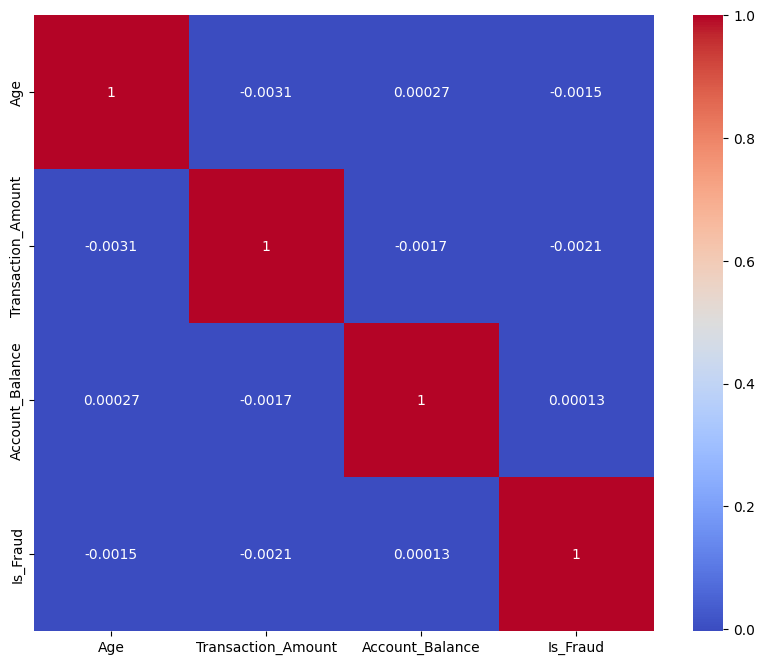

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')

plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

temp_df = df.copy()

for col in temp_df.select_dtypes(include=['object', 'string']):
    temp_df[col] = LabelEncoder().fit_transform(temp_df[col].astype(str))

X = temp_df.drop('Is_Fraud', axis=1)
y = temp_df['Is_Fraud']

rf = RandomForestClassifier()
rf.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance)

                    Feature  Importance
7        Transaction_Amount    0.087754
6          Transaction_Time    0.086776
11          Account_Balance    0.086739
8               Merchant_ID    0.086023
16         Customer_Contact    0.085951
18           Customer_Email    0.084751
17  Transaction_Description    0.071871
1                       Age    0.060950
5          Transaction_Date    0.053346
13     Transaction_Location    0.049117
3                      City    0.048817
12       Transaction_Device    0.045652
2                     State    0.043408
10        Merchant_Category    0.030569
9          Transaction_Type    0.025656
14              Device_Type    0.023482
4              Account_Type    0.017760
0                    Gender    0.011376
15     Transaction_Currency    0.000000
